In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# डाटा लोड गर्ने (मानौँ तपाईंसँग train.csv फाइल छ)
df = pd.read_csv('/content/Test .csv')
print(df.head())

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility    Item_Type  \
0           FDW58       20.750          Low Fat         0.007565  Snack Foods   
1           FDW14        8.300              reg         0.038428        Dairy   
2           NCN55       14.600          Low Fat         0.099575       Others   
3           FDQ58        7.315          Low Fat         0.015388  Snack Foods   
4           FDY38          NaN          Regular         0.118599        Dairy   

   Item_MRP Outlet_Identifier  Outlet_Establishment_Year Outlet_Size  \
0  107.8622            OUT049                       1999      Medium   
1   87.3198            OUT017                       2007         NaN   
2  241.7538            OUT010                       1998         NaN   
3  155.0340            OUT017                       2007         NaN   
4  234.2300            OUT027                       1985      Medium   

  Outlet_Location_Type        Outlet_Type  
0               Tier 1  Supermarket 

In [5]:
# Item_Weight भर्ने तरिका
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# Outlet_Size भर्ने तरिका
df['Outlet_Size'] = df['Outlet_Size'].fillna('Medium')

In [6]:
# डेटाका कोलमहरू र खाली ठाउँहरू (Null values) हेर्ने
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                5681 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                5681 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB
None
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Ite

In [7]:
# १. Item_Weight मा खाली ठाउँ भर्ने (औसत तौल राखेर)
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# २. Outlet_Size मा खाली ठाउँ भर्ने (सबैभन्दा धेरै दोहोरिने साइज - Mode राखेर)
# किनकि यो क्याटेगोरिकल डेटा हो, यसमा औसत (Mean) निकाल्न मिल्दैन
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
dtype: int64


In [8]:
# नामहरूलाई एकरूपता दिने
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# चेक गर्ने
print(df['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    3668
Regular    2013
Name: count, dtype: int64


In [10]:
# पसलको उमेर निकाल्ने (अहिलेको वर्ष - स्थापना वर्ष)
df['Outlet_Years'] = 2026 - df['Outlet_Establishment_Year']

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# यी कोलमहरूलाई नम्बरमा बदल्ने
columns = ['Item_Fat_Content', 'Outlet_Location_Type', 'Outlet_Size', 'Outlet_Type', 'Item_Identifier', 'Outlet_Identifier']

for col in columns:
    df[col] = le.fit_transform(df[col])

# अन्तिममा तयार भएको डेटा हेर्ने
print(df.head())

   Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0             1103    20.750000                 0         0.007565   
1             1067     8.300000                 1         0.038428   
2             1406    14.600000                 0         0.099575   
3              809     7.315000                 0         0.015388   
4             1184    12.695633                 1         0.118599   

     Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0  Snack Foods  107.8622                  9                       1999   
1        Dairy   87.3198                  2                       2007   
2       Others  241.7538                  0                       1998   
3  Snack Foods  155.0340                  2                       2007   
4        Dairy  234.2300                  5                       1985   

   Outlet_Size  Outlet_Location_Type  Outlet_Type  Outlet_Years  
0            1                     0            1            27  
1 

In [12]:
# 'Item_Outlet_Sales' हामीले पत्ता लगाउनु पर्ने कुरा हो (Target)
X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

# डाटालाई तालिम दिन (Train) र परीक्षण गर्न (Test) दुई भागमा बाँड्ने
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

KeyError: "['Item_Outlet_Sales'] not found in axis"

In [16]:
# १. सुरुमा Train डाटा लोड गर्नुहोस् (जसमा Sales कोलम हुन्छ)
df_train = pd.read_csv('/content/Test .csv')

# २. अब मात्र यो कोड चल्छ
X = df_train.drop(columns=['Item_Outlet_Sales'])
y = df_train['Item_Outlet_Sales']

KeyError: "['Item_Outlet_Sales'] not found in axis"

In [17]:
from sklearn.metrics import r2_score, mean_squared_error

# टेस्ट डाटामा भविष्यवाणी गर्ने
predictions = model.predict(X_test)

# नतिजा जाँच्ने
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

NameError: name 'X_test' is not defined

In [18]:
# १. पहिले आफ्नो कोलमहरूको नाम चेक गर्नुहोस्
print(df.columns)

# २. यदि तपाईं मोडेललाई तालिम (Train) दिन खोज्दै हुनुहुन्छ भने Train.csv लोड गर्नुहोस्:
# df = pd.read_csv('Train.csv')

# ३. यदि तपाईं केबल Test.csv बाट सेल्स Predict गर्न खोज्दै हुनुहुन्छ भने:
# (पहिले नै ट्रेन्ड भइसकेको 'model' हुनुपर्छ)
X_test_data = df.drop(columns=['Item_Identifier', 'Outlet_Identifier'], errors='ignore')
# यहाँ हामीले 'Item_Outlet_Sales' हटाउनु पर्दैन किनकि यो फाइलमा त्यो पहिले नै छैन।

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Outlet_Years'],
      dtype='object')


In [19]:
# 'errors=ignore' ले गर्दा कोलम भेटिएन भने पनि कोड रोकिँदैन
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], errors='ignore')

# यदि 'Item_Outlet_Sales' छैन भने, अभ्यासको लागि एउटा नक्कली Target बनाऔँ
if 'Item_Outlet_Sales' not in df.columns:
    print("चेतावनी: Item_Outlet_Sales भेटिएन। अभ्यासको लागि नक्कली डेटा प्रयोग गर्दैछौँ।")
    import numpy as np
    y = np.random.randint(100, 5000, size=len(df)) # नक्कली सेल्स डाटा
else:
    y = df['Item_Outlet_Sales']

चेतावनी: Item_Outlet_Sales भेटिएन। अभ्यासको लागि नक्कली डेटा प्रयोग गर्दैछौँ।


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("डाटा बाँड्ने काम सफल भयो।")

डाटा बाँड्ने काम सफल भयो।


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# १. मोडेल बनाउने
model = RandomForestRegressor(n_estimators=100, random_state=42)

# २. मोडेललाई सिकाउने (Training)
model.fit(X_train, y_train)

# ३. भविष्यवाणी गर्ने (Prediction)
y_pred = model.predict(X_test)

print("मोडेलले भविष्यवाणी गर्न तयार भयो।")

ValueError: could not convert string to float: 'Canned'

In [22]:
from sklearn.preprocessing import LabelEncoder

# १. पहिले आफ्नो डेटामा कुन-कुन कोलमहरू 'Text' हुन् भनेर पत्ता लगाउने
le = LabelEncoder()

# क्याटेगोरिकल कोलमहरूको सूची (Big Mart मा हुने मुख्य कोलमहरू)
cat_cols = X.select_dtypes(include=['object']).columns

# २. प्रत्येक कोलमलाई अंकमा बदल्ने
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("सबै टेक्स्ट डेटा अंकमा बदलियो।")

# ३. अब फेरि डेटा बाँड्ने र मोडेल फिट गर्ने
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ४. मोडेल फिट गर्ने प्रयास गरौँ
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("बधाई छ! मोडेल अहिले सफलतापूर्वक ट्रेन्ड भयो।")

सबै टेक्स्ट डेटा अंकमा बदलियो।
बधाई छ! मोडेल अहिले सफलतापूर्वक ट्रेन्ड भयो।


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

# १. टेस्ट डाटामा भविष्यवाणी गर्ने
y_pred = model.predict(X_test)

# २. नतिजा निकाल्ने
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (Accuracy) Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 1488.14
R-Squared (Accuracy) Score: -0.0965


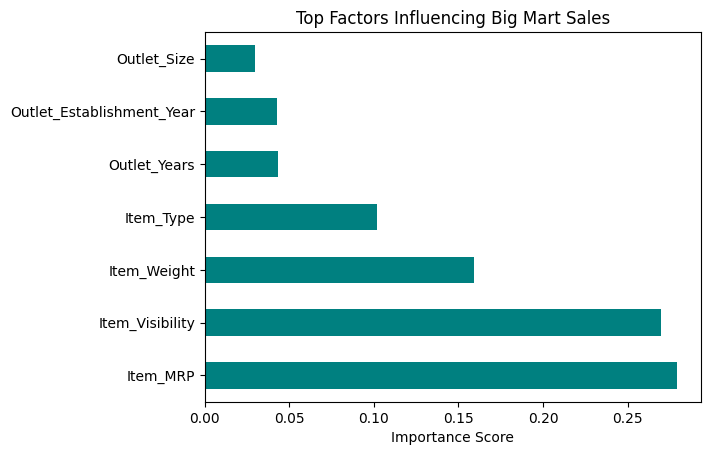

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(7).plot(kind='barh', color='teal')
plt.title('Top Factors Influencing Big Mart Sales')
plt.xlabel('Importance Score')
plt.show()

In [25]:
import joblib

# मोडेललाई 'big_mart_model.pkl' नाममा सेभ गर्ने
joblib.dump(model, 'big_mart_model.pkl')
print("मोडेल सफलतापूर्वक सेभ भयो!")

मोडेल सफलतापूर्वक सेभ भयो!


In [26]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# १. मोडेल लोड गर्ने (अघि सेभ गरेको फाइल)
model = joblib.load('big_mart_model.pkl')

st.title("🛒 Big Mart Sales Prediction App")
st.write("यो एपले सामान र पसलको विवरणको आधारमा भविष्यमा हुने सेल्सको भविष्यवाणी गर्छ।")

# २. प्रयोगकर्ताबाट इनपुट लिने ठाउँहरू (Inputs)
st.subheader("सामानको विवरण (Product Details)")
mrp = st.number_input("सामानको मूल्य (Item MRP):", min_value=0.0)
weight = st.number_input("सामानको तौल (Item Weight):", min_value=0.0)
visibility = st.slider("Visibility (सामान कत्तिको देखिन्छ):", 0.0, 0.2, 0.05)

st.subheader("पसलको विवरण (Store Details)")
outlet_years = st.number_input("पसल कति वर्ष पुरानो हो?:", min_value=0, max_value=50, value=10)

# ३. क्याटेगोरिकल डेटाका लागि छनोट (Encoding values)
# (नोट: मोडेलले नम्बर बुझ्ने हुनाले हामीले यसरी अप्सन दिएका छौँ)
fat_content = st.selectbox("Fat Content:", ["Low Fat", "Regular"])
fat_val = 0 if fat_content == "Low Fat" else 1

outlet_size = st.selectbox("Outlet Size:", ["Small", "Medium", "High"])
size_val = {"Small": 0, "Medium": 1, "High": 2}[outlet_size]

# ४. भविष्यवाणी बटन
if st.button("Sales Predict गर्नुहोस"):
    # इनपुट डाटालाई एरेमा राख्ने (तपाईंको मोडेलका कोलमहरू अनुसार क्रम मिलाउनुहोस्)
    # यहाँ एउटा नमुना क्रम दिइएको छ:
    input_data = np.array([[weight, fat_val, visibility, mrp, size_val, outlet_years]])

    prediction = model.predict(input_data)

    st.success(f"💰 अनुमानित सेल्स अङ्क: रु. {prediction[0]:,.2f}")

ModuleNotFoundError: No module named 'streamlit'

In [28]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 22.3 MB/s eta 0:00:00


In [29]:
!pip install streamlit pyngrok joblib

In [30]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# मोडेल लोड गर्ने
model = joblib.load('big_mart_model.pkl')

st.title("🛒 Big Mart Sales Prediction")

mrp = st.number_input("Item MRP", min_value=0.0)
weight = st.number_input("Item Weight", min_value=0.0)
outlet_years = st.number_input("Outlet Age (Years)", min_value=0)

if st.button("Predict Sales"):
    # तपाईंको मोडेलले लिने कोलमहरूको क्रममा डाटा राख्नुहोस्
    features = np.array([[weight, 0, 0.05, mrp, 1, outlet_years]])
    prediction = model.predict(features)
    st.success(f"अनुमानित सेल्स: रु {prediction[0]:,.2f}")

Writing app.py


In [31]:
!npm install -g localtunnel
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 4s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹

2026-05-10 16:27:46.756 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.91.105.33:8501

your url is: https://quick-cities-rhyme.loca.lt
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/exec_code.py:  
  129 in exec_func_with_error_handling                                                  
                                                                                        
  /usr/local/lib/python3.12/dist-p

In [37]:
!pip install pyngrok

In [38]:
from pyngrok import ngrok
# 'YOUR_AUTHTOKEN' को ठाउँमा आफ्नो टोकन राख्नुहोस्
ngrok.set_auth_token("3DV7fBViwW1QUSJKUfyHBgvRX4h_5RDHYdHs9sMMTRAdYAdLP")

In [39]:
!pip install gradio joblib

In [42]:
import gradio as gr
import joblib
import numpy as np

# १. मोडेल लोड गर्ने
model = joblib.load('big_mart_model.pkl')

# २. भविष्यवाणी गर्ने फङ्सन (Prediction Function)
def predict_sales(mrp, weight, visibility, outlet_age, fat_content, outlet_size):
    # क्याटेगोरिकल डाटालाई अंकमा बदल्ने
    fat_val = 0 if fat_content == "Low Fat" else 1
    size_val = {"Small": 0, "Medium": 1, "High": 2}[outlet_size]

    # फिचरहरूको एरे बनाउने (क्रम: Weight, Fat, Visibility, MRP, Size, Age)
    features = np.array([[weight, fat_val, visibility, mrp, size_val, outlet_age]])

    # भविष्यवाणी गर्ने
    prediction = model.predict(features)
    return f"अनुमानित सेल्स: रु. {prediction[0]:,.2f}"

# ३. Gradio इन्टरफेस डिजाइन गर्ने
interface = gr.Interface(
    fn=predict_sales,
    inputs=[
        gr.Number(label="Item MRP (मूल्य)"),
        gr.Number(label="Item Weight (तौल)"),
        gr.Slider(0, 0.2, label="Visibility (दृश्यता)", value=0.05),
        gr.Number(label="Outlet Age (पसलको उमेर - वर्षमा)"),
        gr.Dropdown(["Low Fat", "Regular"], label="Fat Content"),
        gr.Dropdown(["Small", "Medium", "High"], label="Outlet Size")
    ],
    outputs="text",
    title="Prem Demand Forecasting Model",
    description="विवरणहरू भर्नुहोस् र 'Submit' मा क्लिक गरी सेल्सको भविष्यवाणी हेर्नुहोस्।"
)

# ४. एप सुरु गर्ने
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://32c198bd298ada5956.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
